Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


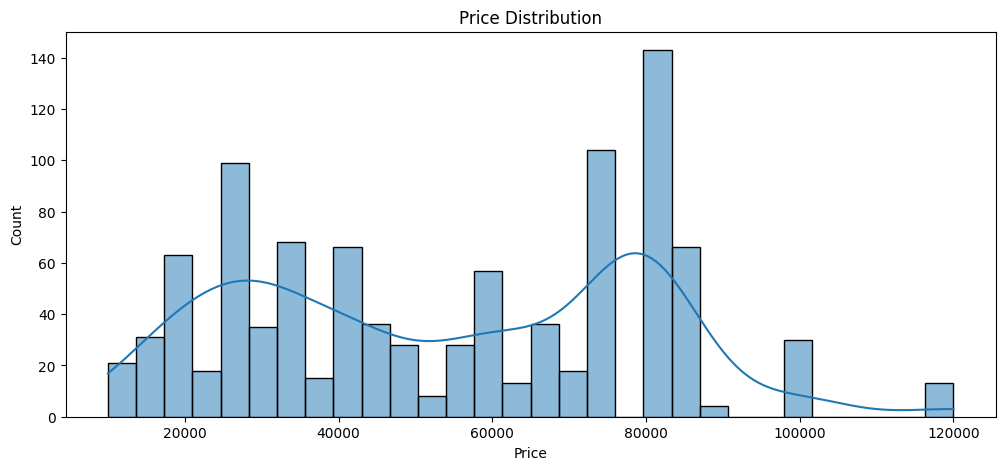

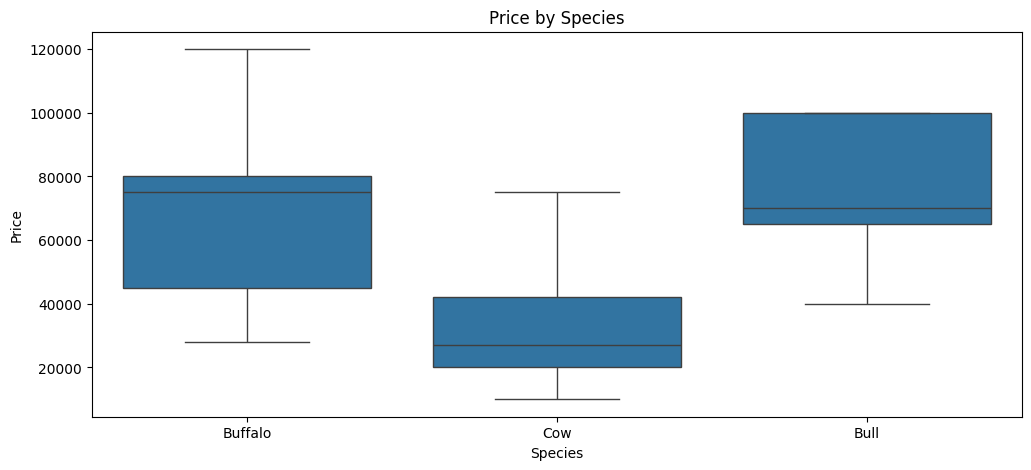

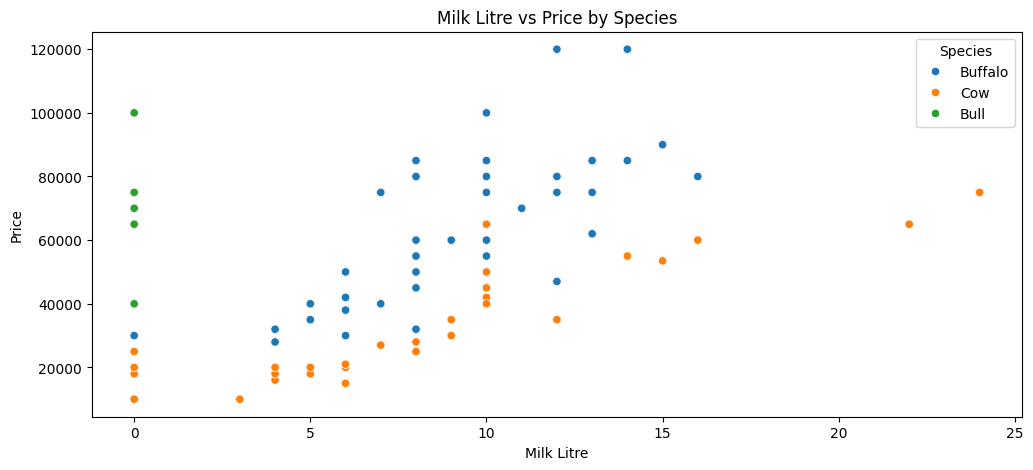


LinearRegression performance:
R2 Score: 0.7686
RMSE: 12264.44
MAE: 9224.12


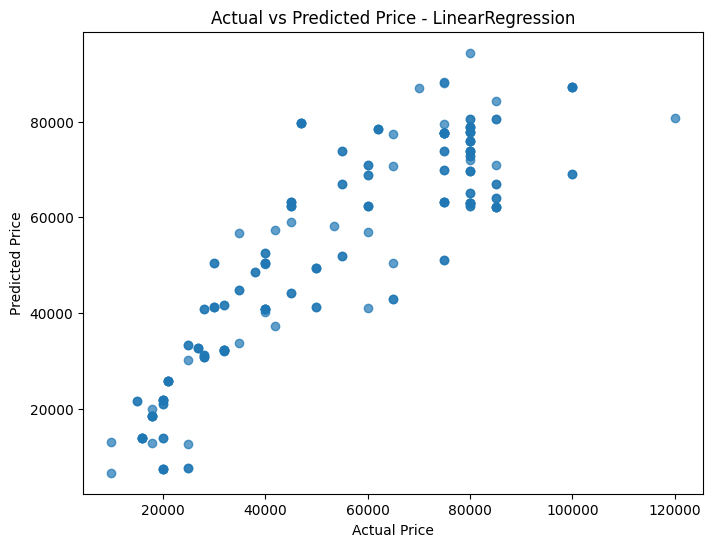


Ridge performance:
R2 Score: 0.7675
RMSE: 12292.59
MAE: 9267.59


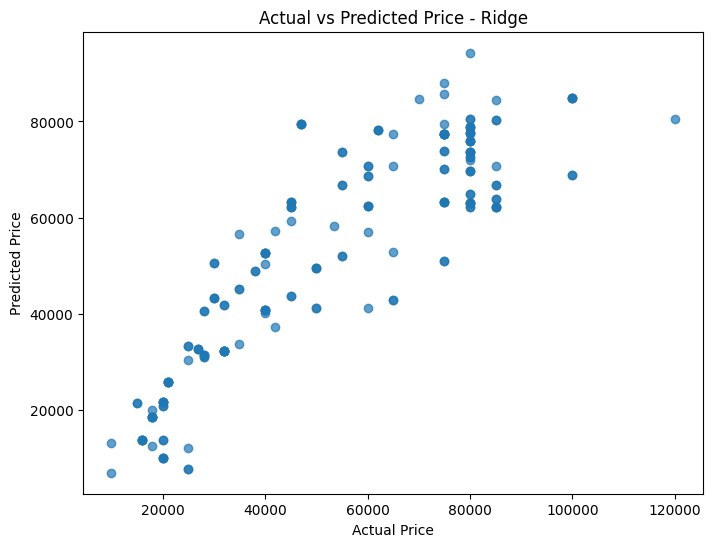


Lasso performance:
R2 Score: 0.7686
RMSE: 12264.93
MAE: 9227.30


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.613e+09, tolerance: 5.405e+07
  model = cd_fast.enet_coordinate_descent(


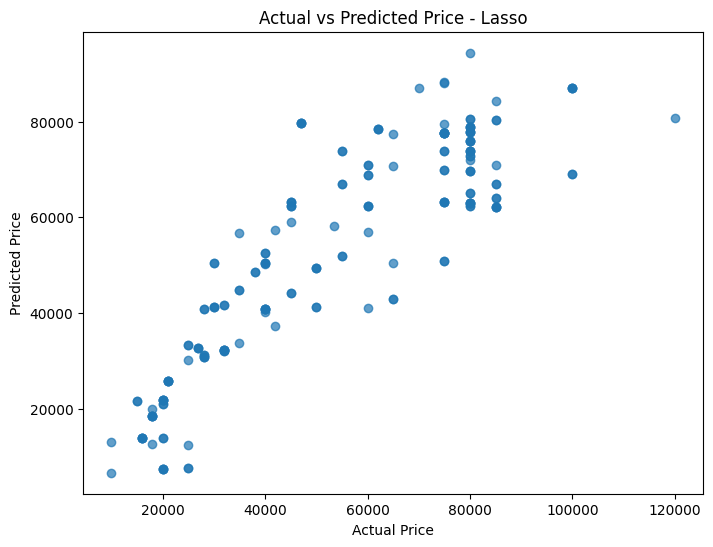


RandomForest performance:
R2 Score: 0.9575
RMSE: 5258.40
MAE: 1496.63


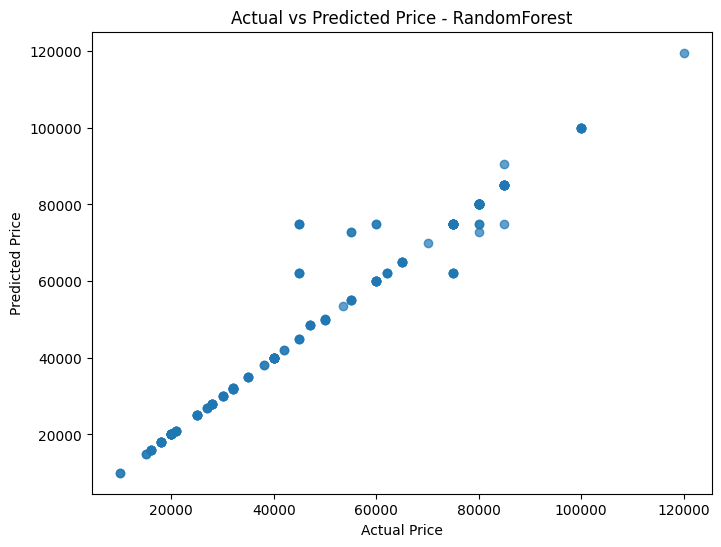

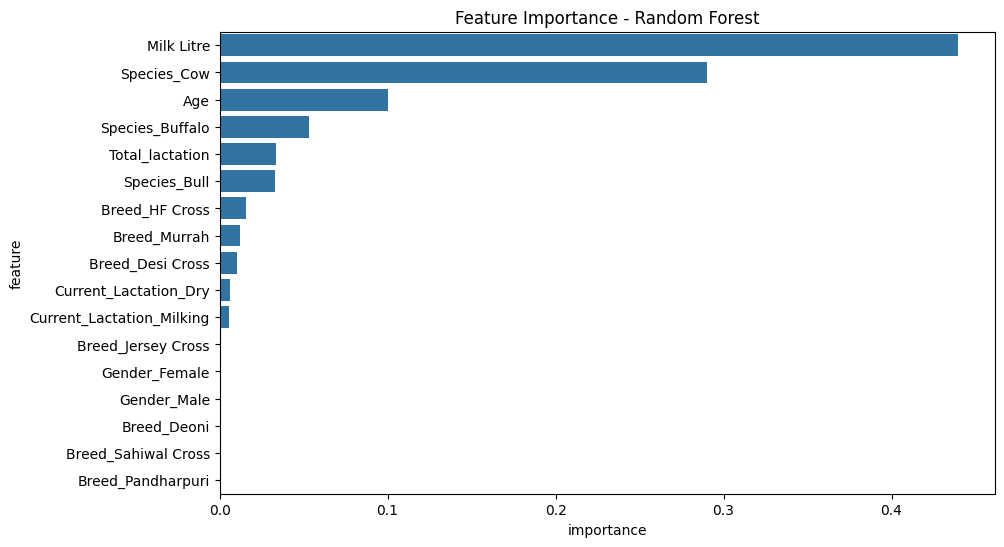


Predicted price for new sample: 74440.0

Final Random Forest model performance on test data:
R2 Score: 0.9575
RMSE: 5258.40
MAE: 1496.63


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Load the data
df = pd.read_excel("/content/drive/MyDrive/Price Prediction/animals_1000_expanded.xlsx")

# Feature engineering: Calculate Age from Cattle_dob
CURRENT_YEAR = 2025
df['Age'] = CURRENT_YEAR - df['Cattle_dob']

# Data exploration plots
plt.figure(figsize=(12,5))
sns.histplot(df['Price'], bins=30, kde=True)
plt.title('Price Distribution')
plt.show()

plt.figure(figsize=(12,5))
sns.boxplot(x='Species', y='Price', data=df)
plt.title('Price by Species')
plt.show()

plt.figure(figsize=(12,5))
sns.scatterplot(x='Milk Litre', y='Price', hue='Species', data=df)
plt.title('Milk Litre vs Price by Species')
plt.show()

# Prepare features and target
X = df[['Species', 'Breed', 'Gender', 'Age', 'Total_lactation', 'Current_Lactation', 'Milk Litre']]
y = df['Price']

# Define categorical and numerical features
categorical_cols = ['Species', 'Breed', 'Gender', 'Current_Lactation']
numerical_cols = ['Age', 'Total_lactation', 'Milk Litre']

# Preprocessing pipeline
column_trans = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    (StandardScaler(), numerical_cols),
    remainder='drop'
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models to compare
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'RandomForest': RandomForestRegressor(random_state=42),
}

results = {}

for name, model in models.items():
    pipe = make_pipeline(column_trans, model)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    print(f"\n{name} performance:")
    print(f"R2 Score: {r2:.4f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")

    plt.figure(figsize=(8,6))
    plt.scatter(y_test, y_pred, alpha=0.7)
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.title(f'Actual vs Predicted Price - {name}')
    plt.show()

# Train Random Forest again for feature importance and final prediction
rf_pipe = make_pipeline(column_trans, RandomForestRegressor(random_state=42))
rf_pipe.fit(X_train, y_train)

# Feature importance
best_rf = rf_pipe.named_steps['randomforestregressor']
ohe_features = rf_pipe.named_steps['columntransformer'].named_transformers_['onehotencoder'].get_feature_names_out(categorical_cols)
all_features = list(ohe_features) + numerical_cols
importances = best_rf.feature_importances_

feat_imp_df = pd.DataFrame({'feature': all_features, 'importance': importances}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feat_imp_df)
plt.title('Feature Importance - Random Forest')
plt.show()

# Save trained Random Forest model pipeline
joblib.dump(rf_pipe, '/content/drive/MyDrive/Price Prediction/cattle_price_rf_model.pkl')

# Predict price for new sample
new_sample = pd.DataFrame({
    'Species': ['Buffalo'],
    'Breed': ['Murrah'],
    'Gender': ['Female'],
    'Age': [CURRENT_YEAR - 2020],
    'Total_lactation': [2],
    'Current_Lactation': ['Milking'],
    'Milk Litre': [10]
})

predicted_price = rf_pipe.predict(new_sample)
print("\nPredicted price for new sample:", predicted_price[0])

# Final evaluation metrics on test set
y_test_pred = rf_pipe.predict(X_test)
r2 = r2_score(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae = mean_absolute_error(y_test, y_test_pred)

print("\nFinal Random Forest model performance on test data:")
print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
